### Black and white image colorization with OpenCV and Deep Learning

##### 1. Importing Libraries

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
!wget https://raw.githubusercontent.com/fatahrahimi330/100-Machine-Learning-Projects/master/13-Black%20and%20white%20image%20colorization/image.png -O black_white.png

--2026-03-02 12:21:53--  https://raw.githubusercontent.com/fatahrahimi330/100-Machine-Learning-Projects/master/13-Black%20and%20white%20image%20colorization/image.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2891941 (2.8M) [image/png]
Saving to: ‘black_white.png’

black_white.png     100%[===================>]   2.76M  --.-KB/s    in 0.07s   

2026-03-02 12:21:53 (42.2 MB/s) - ‘black_white.png’ saved [2891941/2891941]



In [50]:
img_bgr = cv2.imread('black_white.png')

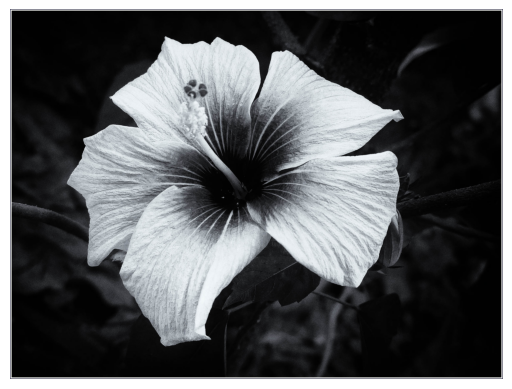

In [51]:
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [52]:
!wget -q https://raw.githubusercontent.com/richzhang/colorization/caffe/colorization/models/colorization_deploy_v2.prototxt -O colorization_deploy_v2.prototxt && echo "✓ prototxt downloaded"

✓ prototxt downloaded


In [53]:
!wget -q https://raw.githubusercontent.com/richzhang/colorization/caffe/colorization/resources/pts_in_hull.npy -O pts_in_hull.npy && echo "✓ pts_in_hull downloaded"

✓ pts_in_hull downloaded


In [54]:
!wget "https://www.dropbox.com/scl/fi/d8zffur3wmd4wet58dp9x/colorization_release_v2.caffemodel?rlkey=iippu6vtsrox3pxkeohcuh4oy&dl=1" -O colorization_release_v2.caffemodel

--2026-03-02 13:03:28--  https://www.dropbox.com/scl/fi/d8zffur3wmd4wet58dp9x/colorization_release_v2.caffemodel?rlkey=iippu6vtsrox3pxkeohcuh4oy&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucf810bd5c8cdca5ee81912a3eab.dl.dropboxusercontent.com/cd/0/inline/C747oyS2EK0mmZMihqWwX7cGodDVpYS63iVnSIwlfZFfBrGBO3Ynx7baBJm79n_0B_2zZSO4f6loLXUwWj7m2SHQlaKEuClKMKg1ApK0qUKXyH5TvCnSa5JzW4T1HRctECAkaS9K3JFUN9Hu903jnphC/file?dl=1# [following]
--2026-03-02 13:03:29--  https://ucf810bd5c8cdca5ee81912a3eab.dl.dropboxusercontent.com/cd/0/inline/C747oyS2EK0mmZMihqWwX7cGodDVpYS63iVnSIwlfZFfBrGBO3Ynx7baBJm79n_0B_2zZSO4f6loLXUwWj7m2SHQlaKEuClKMKg1ApK0qUKXyH5TvCnSa5JzW4T1HRctECAkaS9K3JFUN9Hu903jnphC/file?dl=1
Resolving ucf810bd5c8cdca5ee81912a3eab.dl.dropboxusercontent.com (ucf810bd5c8cdca5ee81912a3eab.dl.dropboxuse

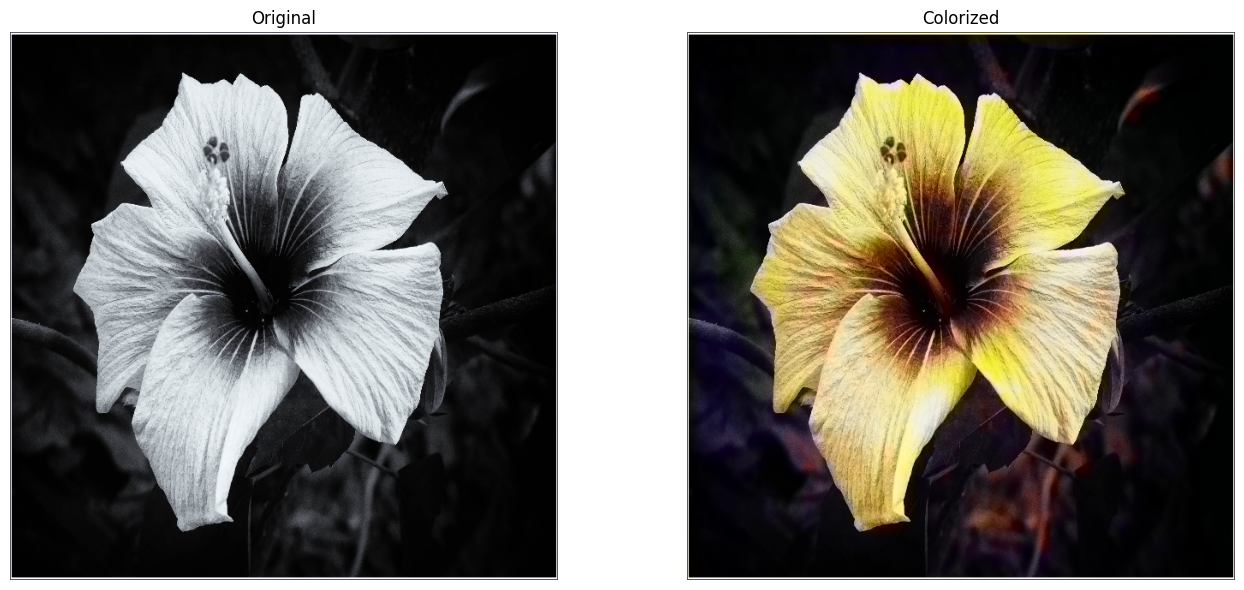

Saved colorized.png


In [55]:
import os
import cv2
import numpy as np
from cv2 import dnn

#--------Model file paths--------#
proto_file = 'colorization_deploy_v2.prototxt'
model_file = 'colorization_release_v2.caffemodel'
hull_pts = 'pts_in_hull.npy'
#--------------#--------------#

# Validate required files
for f in [proto_file, model_file, hull_pts]:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing file: {f}")

if os.path.getsize(hull_pts) < 1024:
    raise ValueError("pts_in_hull.npy is empty/corrupted. Re-run cell 8 to download again.")

#--------Reading the model params--------#
net = dnn.readNetFromCaffe(proto_file, model_file)
kernel = np.load(hull_pts)
#-----------------------------------#---------------------#

#-----Reading and preprocessing image--------#
img = img_bgr.copy()
scaled = img.astype("float32") / 255.0
lab_img = cv2.cvtColor(scaled, cv2.COLOR_BGR2LAB)
#-----------------------------------#---------------------#

# add the cluster centers as 1x1 convolutions to the model
class8 = net.getLayerId("class8_ab")
conv8 = net.getLayerId("conv8_313_rh")
pts = kernel.transpose().reshape(2, 313, 1, 1)
net.getLayer(class8).blobs = [pts.astype("float32")]
net.getLayer(conv8).blobs = [np.full([1, 313], 2.606, dtype="float32")]
#-----------------------------------#---------------------#

# we'll resize the image for the network
resized = cv2.resize(lab_img, (224, 224))
L = cv2.split(resized)[0]
L -= 50
#-----------------------------------#---------------------#

# predicting the ab channels from the input L channel
net.setInput(cv2.dnn.blobFromImage(L))
ab_channel = net.forward()[0, :, :, :].transpose((1, 2, 0))
ab_channel = cv2.resize(ab_channel, (img.shape[1], img.shape[0]))

# Take the L channel from the image
L = cv2.split(lab_img)[0]

# Join the L channel with predicted ab channel
colorized = np.concatenate((L[:, :, np.newaxis], ab_channel), axis=2)

# Then convert the image from Lab to BGR
colorized = cv2.cvtColor(colorized, cv2.COLOR_LAB2BGR)
colorized = np.clip(colorized, 0, 1)
colorized = (255 * colorized).astype("uint8")

# Display in notebook (avoid cv2.imshow)
img_show = cv2.cvtColor(cv2.resize(img, (640, 640)), cv2.COLOR_BGR2RGB)
col_show = cv2.cvtColor(cv2.resize(colorized, (640, 640)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_show)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(col_show)
axes[1].set_title('Colorized')
axes[1].axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite('colorized.png', colorized)
print('Saved colorized.png')